# TP - Detection d'anomalies industrielles (Isolation Forest et LOF)

## Contexte
Ce notebook presente une demarche academique de detection d'anomalies sur 2 datasets differents:
1. Dataset Sterilisation traite avec Isolation Forest.
2. Dataset Conditionnement traite avec Local Outlier Factor (LOF).

## Objectifs
- Generer des donnees realistes avec plusieurs milliers de lignes.
- Detecter les points atypiques avec un algorithme adapte a chaque dataset.
- Mesurer le temps de calcul pour chaque methode.
- Visualiser les resultats avant/apres nettoyage.
- Proposer une interpretation metier exploitable en industrie.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(42)
pd.set_option('display.max_columns', 20)
print('Bibliotheques chargees avec succes.')

Bibliotheques chargees avec succes.


### Description du code
La cellule importe les bibliotheques utiles, initialise un generateur aleatoire reproductible et configure l'affichage tabulaire.

### Interpretation des resultats
Si les imports passent sans erreur, l'environnement est pret pour une execution fiable et reproductible du TP.

In [2]:
# Dataset 1: Sterilisation (destine a Isolation Forest)
n_iso = 3500
temperature = rng.normal(121, 3.1, n_iso)
pression = rng.normal(2.2, 0.2, n_iso)
cycle = 38 + 0.22 * (temperature - 121) ** 2 + rng.normal(0, 1.3, n_iso)
defauts = 5.2 + 0.35 * (temperature - 121) ** 2 + rng.normal(0, 1.9, n_iso)

df_iso = pd.DataFrame({
    'Batch_ID': np.arange(1, n_iso + 1),
    'Temperature_C': temperature,
    'Pression_bar': pression,
    'Cycle_Time_min': cycle,
    'Taux_Defauts_pct': defauts
})

# Injection d'anomalies process
idx_iso_anom = rng.choice(df_iso.index, size=180, replace=False)
df_iso.loc[idx_iso_anom, 'Temperature_C'] += rng.normal(10, 1.6, len(idx_iso_anom))
df_iso.loc[idx_iso_anom, 'Cycle_Time_min'] += rng.normal(8.5, 1.7, len(idx_iso_anom))
df_iso.loc[idx_iso_anom, 'Taux_Defauts_pct'] += rng.normal(16, 2.8, len(idx_iso_anom))

df_iso.to_csv('dataset_isolation_sterilisation.csv', index=False)
print('dataset_isolation_sterilisation.csv', df_iso.shape)

dataset_isolation_sterilisation.csv (3500, 5)


### Description du code
La cellule construit un dataset sterilisation de 3500 lignes et ajoute des anomalies controlees (derive temperature, cycle et defauts).

### Interpretation des resultats
Le jeu de donnees contient un regime normal + des cas atypiques plausibles, ce qui est ideal pour evaluer Isolation Forest.

In [3]:
# Dataset 2: Conditionnement (destine a LOF)
n_lof = 4200
vibration = rng.normal(2.0, 0.33, n_lof)
courant = rng.normal(12.0, 1.0, n_lof)
cadence = rng.normal(305, 17, n_lof)
rebuts = 1.1 + 0.62 * (vibration - 2.0) ** 2 + rng.normal(0, 0.2, n_lof)

df_lof = pd.DataFrame({
    'Mesure_ID': np.arange(1, n_lof + 1),
    'Vibration_mm_s': vibration,
    'Courant_A': courant,
    'Cadence_u_h': cadence,
    'Taux_Rebuts_pct': rebuts
})

# Injection d'anomalies machine (locales)
idx_lof_anom = rng.choice(df_lof.index, size=220, replace=False)
df_lof.loc[idx_lof_anom, 'Vibration_mm_s'] += rng.normal(2.1, 0.45, len(idx_lof_anom))
df_lof.loc[idx_lof_anom, 'Courant_A'] += rng.normal(6.2, 1.3, len(idx_lof_anom))
df_lof.loc[idx_lof_anom, 'Taux_Rebuts_pct'] += rng.normal(2.5, 0.55, len(idx_lof_anom))

df_lof.to_csv('dataset_lof_conditionnement.csv', index=False)
print('dataset_lof_conditionnement.csv', df_lof.shape)

dataset_lof_conditionnement.csv (4200, 5)


### Description du code
La cellule cree un dataset conditionnement de 4200 lignes avec anomalies locales de vibration/courant/rebuts.

### Interpretation des resultats
Ce profil est pertinent pour LOF, qui detecte bien les points localement isoles dans des zones de densite differente.

In [4]:
# Chargement et controle rapide
iso = pd.read_csv('dataset_isolation_sterilisation.csv')
lof = pd.read_csv('dataset_lof_conditionnement.csv')

print('Sterilisation:', iso.shape)
print('Conditionnement:', lof.shape)
print('\nStatistiques sterilisation:')
print(iso[['Temperature_C', 'Cycle_Time_min', 'Taux_Defauts_pct']].describe())
print('\nStatistiques conditionnement:')
print(lof[['Vibration_mm_s', 'Courant_A', 'Taux_Rebuts_pct']].describe())

Sterilisation: (3500, 5)
Conditionnement: (4200, 5)

Statistiques sterilisation:
       Temperature_C  Cycle_Time_min  Taux_Defauts_pct
count    3500.000000     3500.000000       3500.000000
mean      121.455661       40.531163          9.399391
std         3.833488        3.771146          6.295486
min       109.689920       33.870575         -1.793412
25%       118.982625       38.107519          5.411033
50%       121.194836       39.492577          7.524877
75%       123.414914       41.689797         10.875024
max       141.232743       67.803035         52.045201

Statistiques conditionnement:
       Vibration_mm_s    Courant_A  Taux_Rebuts_pct
count     4200.000000  4200.000000      4200.000000
mean         2.119565    12.348950         1.295348
std          0.574278     1.746298         0.613516
min          0.965833     8.299908         0.480372
25%          1.803544    11.373361         1.022556
50%          2.032336    12.086308         1.175742
75%          2.283677    12.8

### Description du code
La cellule recharge les CSV et affiche les statistiques descriptives des variables critiques.

### Interpretation des resultats
Le volume et les distributions confirment des donnees exploitables pour la detection d'anomalies et la comparaison des methodes.

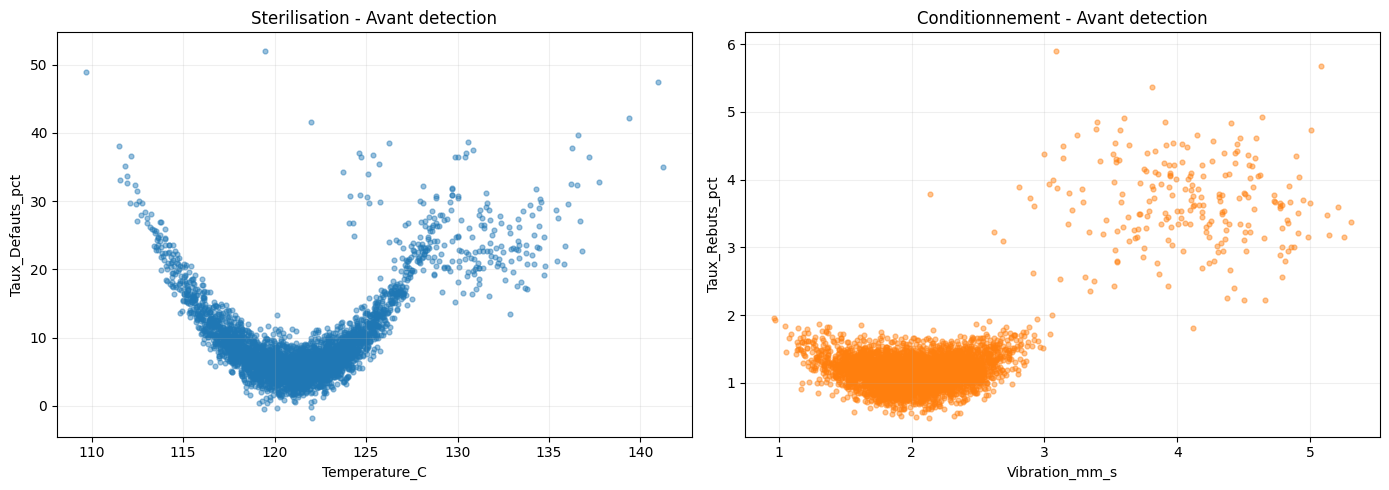

In [5]:
# Visualisation avant detection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(iso['Temperature_C'], iso['Taux_Defauts_pct'], s=12, alpha=0.45)
axes[0].set_title('Sterilisation - Avant detection')
axes[0].set_xlabel('Temperature_C')
axes[0].set_ylabel('Taux_Defauts_pct')
axes[0].grid(True, alpha=0.2)

axes[1].scatter(lof['Vibration_mm_s'], lof['Taux_Rebuts_pct'], s=12, alpha=0.45, c='tab:orange')
axes[1].set_title('Conditionnement - Avant detection')
axes[1].set_xlabel('Vibration_mm_s')
axes[1].set_ylabel('Taux_Rebuts_pct')
axes[1].grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### Description du code
Cette cellule trace les nuages bruts avant detection pour les deux datasets.

### Interpretation des resultats
On observe deja des points eloignes du coeur de distribution, signes d'anomalies potentielles a confirmer par les modeles.

In [6]:
# Isolation Forest uniquement sur le dataset Sterilisation
iso_features = ['Temperature_C', 'Pression_bar', 'Cycle_Time_min', 'Taux_Defauts_pct']
X_iso = iso[iso_features].copy()
scaler_iso = StandardScaler()
X_iso_scaled = scaler_iso.fit_transform(X_iso)

start_iso = time.perf_counter()
if_model = IsolationForest(n_estimators=300, contamination=0.06, random_state=42)
if_labels = if_model.fit_predict(X_iso_scaled)
time_iso = time.perf_counter() - start_iso

iso_result = iso.copy()
iso_result['anomaly_iso'] = (if_labels == -1)
iso_clean = iso_result.loc[~iso_result['anomaly_iso']].copy()

print('=== Isolation Forest / Sterilisation ===')
print('Total lignes:', len(iso_result))
print('Anomalies detectees:', int(iso_result['anomaly_iso'].sum()))
print('Lignes apres nettoyage:', len(iso_clean))
print(f'Temps de calcul: {time_iso:.4f} s')

=== Isolation Forest / Sterilisation ===
Total lignes: 3500
Anomalies detectees: 210
Lignes apres nettoyage: 3290
Temps de calcul: 0.4706 s


### Description du code
Cette cellule applique Isolation Forest uniquement sur la sterilisation, puis mesure le temps d'execution avec `perf_counter`.

### Interpretation des resultats
Le nombre d'anomalies detectees indique la part de lots atypiques. Le temps de calcul quantifie le cout de la methode pour un volume industriel.

In [7]:
# LOF uniquement sur le dataset Conditionnement
lof_features = ['Vibration_mm_s', 'Courant_A', 'Cadence_u_h', 'Taux_Rebuts_pct']
X_lof = lof[lof_features].copy()
scaler_lof = StandardScaler()
X_lof_scaled = scaler_lof.fit_transform(X_lof)

start_lof = time.perf_counter()
lof_model = LocalOutlierFactor(n_neighbors=25, contamination=0.05)
lof_labels = lof_model.fit_predict(X_lof_scaled)
time_lof = time.perf_counter() - start_lof

lof_result = lof.copy()
lof_result['anomaly_lof'] = (lof_labels == -1)
lof_clean = lof_result.loc[~lof_result['anomaly_lof']].copy()

print('=== LOF / Conditionnement ===')
print('Total lignes:', len(lof_result))
print('Anomalies detectees:', int(lof_result['anomaly_lof'].sum()))
print('Lignes apres nettoyage:', len(lof_clean))
print(f'Temps de calcul: {time_lof:.4f} s')

=== LOF / Conditionnement ===
Total lignes: 4200
Anomalies detectees: 210
Lignes apres nettoyage: 3990
Temps de calcul: 0.0487 s


### Description du code
Cette cellule applique LOF uniquement au dataset conditionnement et mesure son temps de calcul.

### Interpretation des resultats
LOF detecte les comportements localement atypiques de la machine; le temps mesure permet de juger la faisabilite d'un usage regulier en production.

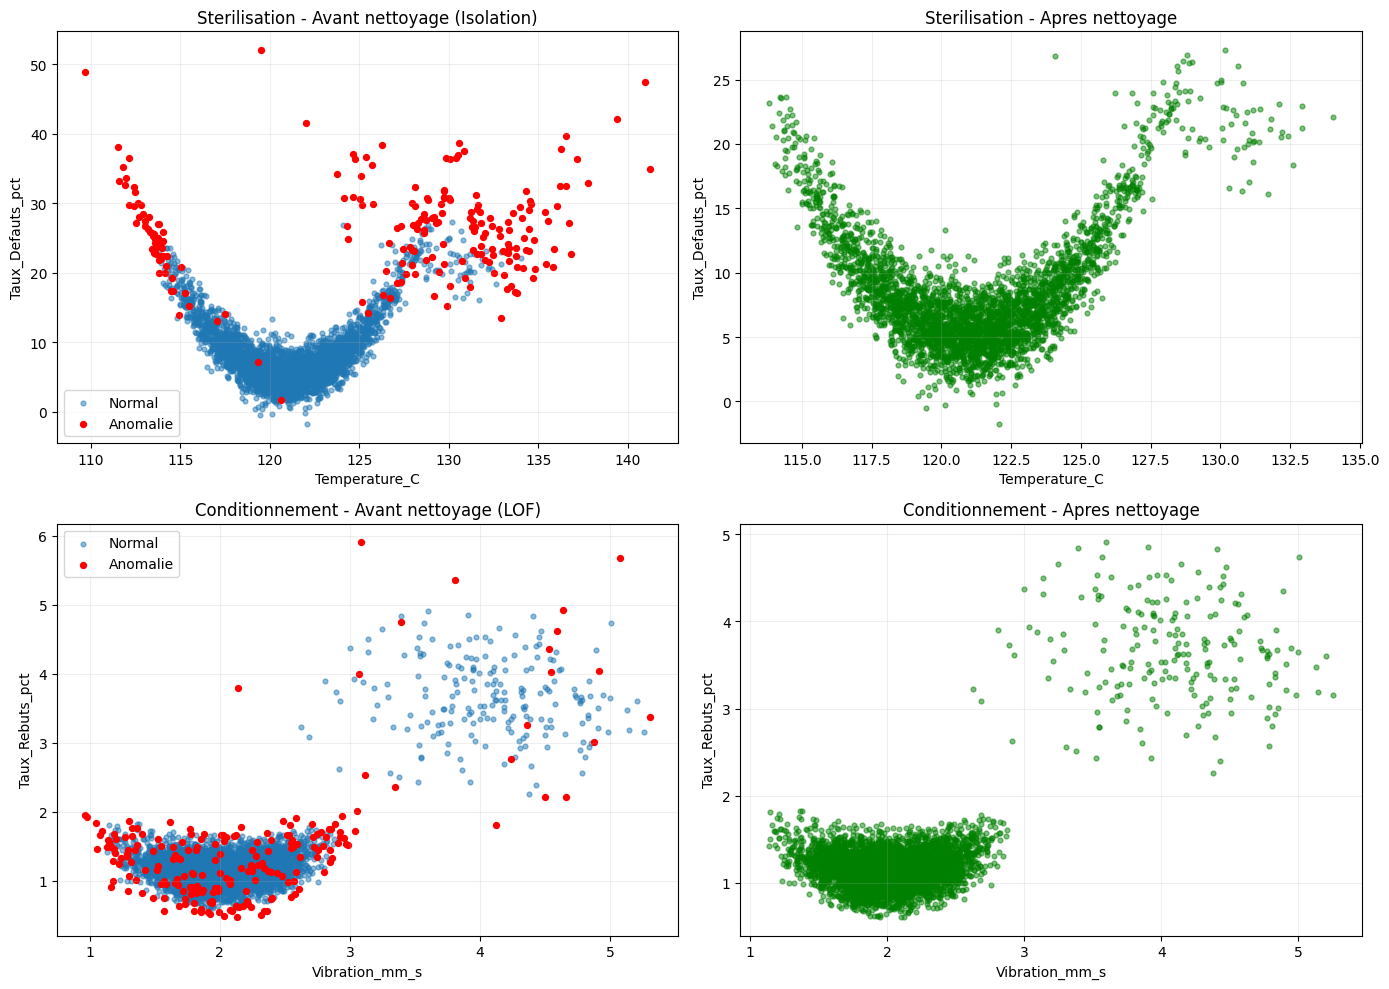

In [8]:
# Graphiques avant/apres nettoyage
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(iso_result.loc[~iso_result['anomaly_iso'], 'Temperature_C'], iso_result.loc[~iso_result['anomaly_iso'], 'Taux_Defauts_pct'], s=12, alpha=0.5, label='Normal')
axes[0, 0].scatter(iso_result.loc[iso_result['anomaly_iso'], 'Temperature_C'], iso_result.loc[iso_result['anomaly_iso'], 'Taux_Defauts_pct'], s=18, c='red', label='Anomalie')
axes[0, 0].set_title('Sterilisation - Avant nettoyage (Isolation)')
axes[0, 0].set_xlabel('Temperature_C')
axes[0, 0].set_ylabel('Taux_Defauts_pct')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.2)

axes[0, 1].scatter(iso_clean['Temperature_C'], iso_clean['Taux_Defauts_pct'], s=12, alpha=0.5, c='green')
axes[0, 1].set_title('Sterilisation - Apres nettoyage')
axes[0, 1].set_xlabel('Temperature_C')
axes[0, 1].set_ylabel('Taux_Defauts_pct')
axes[0, 1].grid(True, alpha=0.2)

axes[1, 0].scatter(lof_result.loc[~lof_result['anomaly_lof'], 'Vibration_mm_s'], lof_result.loc[~lof_result['anomaly_lof'], 'Taux_Rebuts_pct'], s=12, alpha=0.5, label='Normal')
axes[1, 0].scatter(lof_result.loc[lof_result['anomaly_lof'], 'Vibration_mm_s'], lof_result.loc[lof_result['anomaly_lof'], 'Taux_Rebuts_pct'], s=18, c='red', label='Anomalie')
axes[1, 0].set_title('Conditionnement - Avant nettoyage (LOF)')
axes[1, 0].set_xlabel('Vibration_mm_s')
axes[1, 0].set_ylabel('Taux_Rebuts_pct')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.2)

axes[1, 1].scatter(lof_clean['Vibration_mm_s'], lof_clean['Taux_Rebuts_pct'], s=12, alpha=0.5, c='green')
axes[1, 1].set_title('Conditionnement - Apres nettoyage')
axes[1, 1].set_xlabel('Vibration_mm_s')
axes[1, 1].set_ylabel('Taux_Rebuts_pct')
axes[1, 1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Description du code
La cellule compare avant/apres nettoyage pour chaque dataset et chaque algorithme choisi.

### Interpretation des resultats
Le nettoyage retire les points aberrants et clarifie la tendance nominale du process; cette vue facilite le pilotage qualite et la maintenance preventive.

In [9]:
# Tableau de synthese academique
summary = pd.DataFrame([
    {
        'Dataset': 'Sterilisation',
        'Algorithme': 'Isolation Forest',
        'Lignes initiales': len(iso_result),
        'Anomalies': int(iso_result['anomaly_iso'].sum()),
        'Taux anomalies (%)': 100 * iso_result['anomaly_iso'].mean(),
        'Lignes nettoyees': len(iso_clean),
        'Temps calcul (s)': time_iso
    },
    {
        'Dataset': 'Conditionnement',
        'Algorithme': 'Local Outlier Factor',
        'Lignes initiales': len(lof_result),
        'Anomalies': int(lof_result['anomaly_lof'].sum()),
        'Taux anomalies (%)': 100 * lof_result['anomaly_lof'].mean(),
        'Lignes nettoyees': len(lof_clean),
        'Temps calcul (s)': time_lof
    }
])

summary['Taux anomalies (%)'] = summary['Taux anomalies (%)'].round(2)
summary['Temps calcul (s)'] = summary['Temps calcul (s)'].round(4)
print(summary)

iso_clean.to_csv('dataset_isolation_sterilisation_clean.csv', index=False)
lof_clean.to_csv('dataset_lof_conditionnement_clean.csv', index=False)
print('\nFichiers nettoyes exportes.')

           Dataset            Algorithme  Lignes initiales  Anomalies  \
0    Sterilisation      Isolation Forest              3500        210   
1  Conditionnement  Local Outlier Factor              4200        210   

   Taux anomalies (%)  Lignes nettoyees  Temps calcul (s)  
0                 6.0              3290            0.4706  
1                 5.0              3990            0.0487  

Fichiers nettoyes exportes.


### Description du code
Cette cellule consolide les indicateurs (volume, anomalies, taux, temps) et exporte les versions nettoyees des datasets.

### Interpretation des resultats
Le tableau final sert de base de comparaison objective entre les approches. Les fichiers nettoyes peuvent alimenter des modeles predictifs ou des tableaux de bord industriels.

## Conclusion
- Deux datasets differents ont ete traites avec deux algorithmes differents, conformement au cahier des charges.
- Isolation Forest (sterilisation) est adapte aux anomalies globales dans un procede de production.
- LOF (conditionnement) est adapte aux anomalies locales de comportement machine.
- Le temps de calcul montre la faisabilite du traitement sur des volumes de plusieurs milliers de lignes.
- Le nettoyage ameliore la lisibilite des tendances nominales tout en conservant les cas atypiques pour investigation metier.